# Notebook 04: Putirka Benchmarking via Thermobar
Opx ML Thermobarometer
Author: [Your name]
Date: 2026-04-04

Compares ML predictions against Putirka (2008) equations under three conditions:
- Option 1: Thermobar iterative solver (no external P/T)
- Option 2: Putirka with true P/T input (best case)
- Option 3: Putirka with ML-predicted P/T input (operational scenario)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (ROOT, DATA_RAW, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
                    MODELS, FIGURES, RESULTS, LOGS, EXPETDB)

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import Thermobar as pt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## 4.1 Load test set from saved indices

In [2]:
# Load opx-liq dataset (saved by NB03)
df_liq_full = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
test_idx = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
df_test_liq = df_liq_full.loc[test_idx].copy()

OPX_FEAT = ['SiO2','Al2O3','FeO_total','MgO','CaO','Mg_num','Al_IV','Al_VI','En_frac','Fs_frac','Wo_frac','MgTs']
LIQ_OXIDES = ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']
liq_feat = [f'liq_{o}' for o in LIQ_OXIDES] + ['liq_Mg_num']
ALL_FEAT = OPX_FEAT + liq_feat

y_test_T = df_test_liq['T_C'].values
y_test_P = df_test_liq['P_kbar'].values

print(f'Test set: {len(df_test_liq)} opx-liq pairs, {df_test_liq["Citation"].nunique()} studies')

Test set: 170 opx-liq pairs, 19 studies


## 4.2 Format data for Thermobar

In [3]:
opx_test = pd.DataFrame({
    'SiO2_Opx': df_test_liq['SiO2'],
    'TiO2_Opx': df_test_liq['TiO2'].fillna(0),
    'Al2O3_Opx': df_test_liq['Al2O3'],
    'FeOt_Opx': df_test_liq['FeO_total'],
    'MgO_Opx': df_test_liq['MgO'],
    'CaO_Opx': df_test_liq['CaO'],
    'MnO_Opx': df_test_liq['MnO'].fillna(0),
    'Cr2O3_Opx': df_test_liq['Cr2O3'].fillna(0),
    'Na2O_Opx': df_test_liq['Na2O'].fillna(0),
})

liq_test = pd.DataFrame({
    'SiO2_Liq': df_test_liq['liq_SiO2'],
    'TiO2_Liq': df_test_liq['liq_TiO2'].fillna(0),
    'Al2O3_Liq': df_test_liq['liq_Al2O3'],
    'FeOt_Liq': df_test_liq['liq_FeO'],
    'MgO_Liq': df_test_liq['liq_MgO'],
    'CaO_Liq': df_test_liq['liq_CaO'],
    'Na2O_Liq': df_test_liq['liq_Na2O'],
    'K2O_Liq': df_test_liq['liq_K2O'].fillna(0),
    'Fe3Fet_Liq': 0.0,
    'H2O_Liq': 0.0,
})

print(f'Opx: {opx_test.shape}, Liq: {liq_test.shape}')

Opx: (170, 9), Liq: (170, 10)


## 4.3 Option 2: Putirka with true P/T input

In [4]:
P_true = df_test_liq['P_kbar'].values
T_true = df_test_liq['T_C'].values

# Temperature equations (true P input)
print("Option 2: Putirka with true P/T...")
try:
    T_putirka_28a = pt.calculate_opx_liq_temp(
        equationT='T_Put2008_eq28a', opx_comps=opx_test, liq_comps=liq_test,
        P=P_true, Fe3Fet_Liq=0.0, H2O_Liq=0.0)
    print(f"  28a T: {len(T_putirka_28a)} predictions")
except Exception as e:
    print(f"  28a error: {e}")
    T_putirka_28a = None

try:
    T_putirka_28b = pt.calculate_opx_liq_temp(
        equationT='T_Put2008_eq28b_opx_sat', opx_comps=opx_test, liq_comps=liq_test,
        P=P_true, Fe3Fet_Liq=0.0, H2O_Liq=0.0)
    print(f"  28b T: {len(T_putirka_28b)} predictions")
except Exception as e:
    print(f"  28b error: {e}")
    T_putirka_28b = None

# Pressure equations (true T input)
try:
    P_putirka_29a = pt.calculate_opx_liq_press(
        equationP='P_Put2008_eq29a', opx_comps=opx_test, liq_comps=liq_test,
        T=T_true, Fe3Fet_Liq=0.0, H2O_Liq=0.0)
    print(f"  29a P: {len(P_putirka_29a)} predictions")
except Exception as e:
    print(f"  29a error: {e}")
    P_putirka_29a = None

try:
    P_putirka_29c = pt.calculate_opx_only_press(
        equationP='P_Put2008_eq29c', opx_comps=opx_test, T=T_true)
    print(f"  29c P: {len(P_putirka_29c)} predictions")
except Exception as e:
    print(f"  29c error: {e}")
    P_putirka_29c = None

Option 2: Putirka with true P/T...
  28a T: 170 predictions


  28b T: 170 predictions


  29a P: 170 predictions
  29c P: 170 predictions


## 4.4 Option 1: Thermobar iterative solver

In [5]:
print("Option 1: Thermobar iterative solver...")
try:
    iter_result = pt.calculate_opx_liq_press_temp(
        equationT='T_Put2008_eq28a',
        equationP='P_Put2008_eq29a',
        opx_comps=opx_test,
        liq_comps=liq_test,
        Fe3Fet_Liq=0.0,
        H2O_Liq=0.0,
        iterations=30,
        T_K_Guess=1473,
    )
    # Extract results - column names vary by Thermobar version
    if hasattr(iter_result, 'columns'):
        t_col = [c for c in iter_result.columns if 'T' in c and 'K' in c]
        p_col = [c for c in iter_result.columns if 'P' in c and 'kbar' in c]
        if t_col and p_col:
            T_putirka_iter = iter_result[t_col[0]].values - 273.15
            P_putirka_iter = iter_result[p_col[0]].values
        else:
            T_putirka_iter = iter_result.iloc[:, 0].values - 273.15
            P_putirka_iter = iter_result.iloc[:, 1].values
    else:
        T_putirka_iter = np.array(iter_result['T_K_calc']) - 273.15
        P_putirka_iter = np.array(iter_result['P_kbar_calc'])
    print(f"  Iterative: {len(T_putirka_iter)} predictions")
    print(f"  T range: {np.nanmin(T_putirka_iter):.0f}-{np.nanmax(T_putirka_iter):.0f} C")
    print(f"  P range: {np.nanmin(P_putirka_iter):.1f}-{np.nanmax(P_putirka_iter):.1f} kbar")
except Exception as e:
    print(f"  Iterative error: {e}")
    print("  Check Thermobar docs for correct function signature.")
    T_putirka_iter = None
    P_putirka_iter = None

Option 1: Thermobar iterative solver...


  Iterative: 170 predictions
  T range: 1020-1800 C
  P range: -1.8-34.3 kbar


## 4.5 Option 3: Putirka with ML-predicted P/T input

In [6]:
model_T_ml = joblib.load(MODELS / 'model_RF_T_C_opx_liq.joblib')
model_P_ml = joblib.load(MODELS / 'model_RF_P_kbar_opx_liq.joblib')

X_test_ml = df_test_liq[ALL_FEAT].fillna(0).values
ml_T_pred = model_T_ml.predict(X_test_ml)
ml_P_pred = model_P_ml.predict(X_test_ml)

print("Option 3: Putirka with ML-predicted P/T...")
try:
    T_putirka_mlP = pt.calculate_opx_liq_temp(
        equationT='T_Put2008_eq28a', opx_comps=opx_test, liq_comps=liq_test,
        P=ml_P_pred, Fe3Fet_Liq=0.0, H2O_Liq=0.0)
    print(f"  28a T (ML-P input): {len(T_putirka_mlP)} predictions")
except Exception as e:
    print(f"  28a (ML-P) error: {e}")
    T_putirka_mlP = None

try:
    P_putirka_mlT = pt.calculate_opx_liq_press(
        equationP='P_Put2008_eq29a', opx_comps=opx_test, liq_comps=liq_test,
        T=ml_T_pred, Fe3Fet_Liq=0.0, H2O_Liq=0.0)
    print(f"  29a P (ML-T input): {len(P_putirka_mlT)} predictions")
except Exception as e:
    print(f"  29a (ML-T) error: {e}")
    P_putirka_mlT = None

Option 3: Putirka with ML-predicted P/T...
  28a T (ML-P input): 170 predictions


  29a P (ML-T input): 170 predictions


## 4.6 Unified comparison table

In [7]:
def compute_metrics(y_true, y_pred, method, target):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    yt, yp = y_true[valid], y_pred[valid]
    return {
        'Method': method,
        'Target': target,
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAE': mean_absolute_error(yt, yp),
        'R2': r2_score(yt, yp),
        'n_test': len(yt),
    }

rows = []

# Option 2: true P/T input
if T_putirka_28a is not None:
    rows.append(compute_metrics(y_test_T, T_putirka_28a, 'Putirka 28a (true P)', 'T'))
if T_putirka_28b is not None:
    rows.append(compute_metrics(y_test_T, T_putirka_28b, 'Putirka 28b (true P)', 'T'))
if P_putirka_29a is not None:
    rows.append(compute_metrics(y_test_P, P_putirka_29a, 'Putirka 29a (true T)', 'P'))
if P_putirka_29c is not None:
    rows.append(compute_metrics(y_test_P, P_putirka_29c, 'Putirka 29c (opx-only, true T)', 'P'))

# Option 1: iterative
if T_putirka_iter is not None:
    rows.append(compute_metrics(y_test_T, T_putirka_iter, 'Putirka iterative (28a+29a)', 'T'))
if P_putirka_iter is not None:
    rows.append(compute_metrics(y_test_P, P_putirka_iter, 'Putirka iterative (28a+29a)', 'P'))

# Option 3: ML P/T as input
if T_putirka_mlP is not None:
    rows.append(compute_metrics(y_test_T, T_putirka_mlP, 'Putirka 28a (ML P)', 'T'))
if P_putirka_mlT is not None:
    rows.append(compute_metrics(y_test_P, P_putirka_mlT, 'Putirka 29a (ML T)', 'P'))

# ML baseline
rows.append(compute_metrics(y_test_T, ml_T_pred, 'ML-RF opx-liq', 'T'))
rows.append(compute_metrics(y_test_P, ml_P_pred, 'ML-RF opx-liq', 'P'))

comparison = pd.DataFrame(rows)
comparison.to_csv(RESULTS / 'nb04_putirka_comparison.csv', index=False)

print("\n=== Temperature ===")
print(comparison[comparison['Target'] == 'T'].to_string(index=False))
print("\n=== Pressure ===")
print(comparison[comparison['Target'] == 'P'].to_string(index=False))


=== Temperature ===
                     Method Target       RMSE        MAE        R2  n_test
       Putirka 28a (true P)      T 331.683187 311.442828 -2.988801     170
       Putirka 28b (true P)      T 320.057597 295.324325 -2.714084     170
Putirka iterative (28a+29a)      T 120.866429  61.141274  0.472459     143
         Putirka 28a (ML P)      T 328.600212 307.903725 -2.914994     170
              ML-RF opx-liq      T 124.017694  67.924907  0.442349     170

=== Pressure ===
                        Method Target      RMSE      MAE        R2  n_test
          Putirka 29a (true T)      P  7.936756 5.883696  0.358563     143
Putirka 29c (opx-only, true T)      P 19.023074 9.940455 -4.266527     144
   Putirka iterative (28a+29a)      P  5.402282 3.622316  0.702818     143
            Putirka 29a (ML T)      P  8.022813 5.857467  0.344578     143
                 ML-RF opx-liq      P  6.144768 4.281081  0.620836     170


## 4.7 Comparison figures

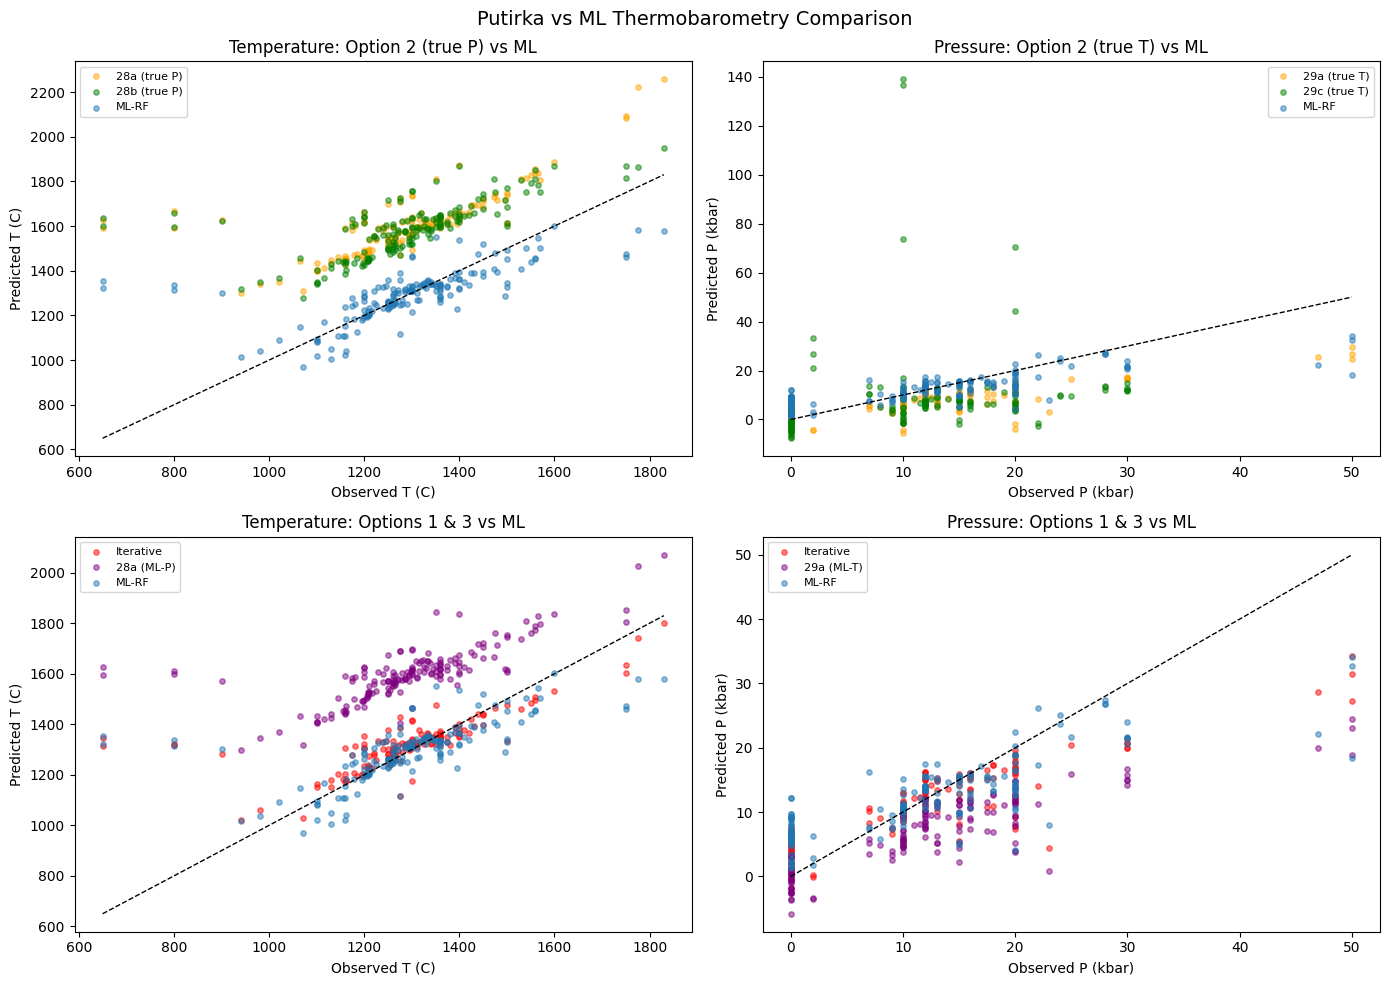

Saved fig_nb04_putirka_comparison.png

Notebook 04 complete.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: T Option 2
ax = axes[0, 0]
if T_putirka_28a is not None:
    ax.scatter(y_test_T, T_putirka_28a, alpha=0.5, s=15, label='28a (true P)', color='orange')
if T_putirka_28b is not None:
    ax.scatter(y_test_T, T_putirka_28b, alpha=0.5, s=15, label='28b (true P)', color='green')
ax.scatter(y_test_T, ml_T_pred, alpha=0.5, s=15, label='ML-RF', color='tab:blue')
lims = [min(y_test_T.min(), 700), max(y_test_T.max(), 1800)]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Observed T (C)')
ax.set_ylabel('Predicted T (C)')
ax.set_title('Temperature: Option 2 (true P) vs ML')
ax.legend(fontsize=8)

# Top-right: P Option 2
ax = axes[0, 1]
if P_putirka_29a is not None:
    ax.scatter(y_test_P, P_putirka_29a, alpha=0.5, s=15, label='29a (true T)', color='orange')
if P_putirka_29c is not None:
    ax.scatter(y_test_P, P_putirka_29c, alpha=0.5, s=15, label='29c (true T)', color='green')
ax.scatter(y_test_P, ml_P_pred, alpha=0.5, s=15, label='ML-RF', color='tab:blue')
lims = [min(y_test_P.min(), 0), max(y_test_P.max(), 50)]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Observed P (kbar)')
ax.set_ylabel('Predicted P (kbar)')
ax.set_title('Pressure: Option 2 (true T) vs ML')
ax.legend(fontsize=8)

# Bottom-left: T Option 1 + 3
ax = axes[1, 0]
if T_putirka_iter is not None:
    ax.scatter(y_test_T, T_putirka_iter, alpha=0.5, s=15, label='Iterative', color='red')
if T_putirka_mlP is not None:
    ax.scatter(y_test_T, T_putirka_mlP, alpha=0.5, s=15, label='28a (ML-P)', color='purple')
ax.scatter(y_test_T, ml_T_pred, alpha=0.5, s=15, label='ML-RF', color='tab:blue')
lims = [min(y_test_T.min(), 700), max(y_test_T.max(), 1800)]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Observed T (C)')
ax.set_ylabel('Predicted T (C)')
ax.set_title('Temperature: Options 1 & 3 vs ML')
ax.legend(fontsize=8)

# Bottom-right: P Option 1 + 3
ax = axes[1, 1]
if P_putirka_iter is not None:
    ax.scatter(y_test_P, P_putirka_iter, alpha=0.5, s=15, label='Iterative', color='red')
if P_putirka_mlT is not None:
    ax.scatter(y_test_P, P_putirka_mlT, alpha=0.5, s=15, label='29a (ML-T)', color='purple')
ax.scatter(y_test_P, ml_P_pred, alpha=0.5, s=15, label='ML-RF', color='tab:blue')
lims = [min(y_test_P.min(), 0), max(y_test_P.max(), 50)]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Observed P (kbar)')
ax.set_ylabel('Predicted P (kbar)')
ax.set_title('Pressure: Options 1 & 3 vs ML')
ax.legend(fontsize=8)

plt.suptitle('Putirka vs ML Thermobarometry Comparison', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(FIGURES / 'fig_nb04_putirka_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig_nb04_putirka_comparison.png')
print('\nNotebook 04 complete.')